# Workflow for a multi-stage stochastic optimization

In this example of the ETHOS.FINE framework, an energy system is optimized as a
**multi-stage stochastic program** (MSSP): the future is described by a *scenario tree*,
and the model has to commit to today's investments before it is known which branch of the
tree will be realized. Later investments may then react to what has been revealed.

This is a different question from the one asked in
[08_Stochastic Optimization](<08_Stochastic Optimization.ipynb>). There,
`stochasticModel=True` optimizes a **single** design that performs well across several
operational years. Here, the design itself is allowed to adapt over time, and the point of
the optimization is to find the *first* decision that is best given everything that could
still happen.

The functionality is provided by `fine.expansionModules.multiStageStochasticProgram`, which
wraps FINE with [mpi-sppy](https://mpi-sppy.readthedocs.io). One independent copy of the
energy system model is built per scenario with that scenario's parameter values, and
mpi-sppy enforces that decisions taken before the scenarios can be told apart are identical
across them (*non-anticipativity*).

What this example shows:

* a **3-stage** tree with **non-uniform** probabilities,
* stages covering a **different number of investment periods** each,
* **two** uncertain parameters that vary together (electricity demand and the gas price),
* the same problem solved via the **extensive form** and via **progressive hedging**.

## 1. Import packages

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import fine as fn
import fine.expansionModules.multiStageStochasticProgram as mssp

## 2. Initialize the deterministic base model

The base model describes the *structure* of the energy system and holds the values of every
parameter that is certain. It is built with the ordinary FINE API; nothing about it is
specific to stochastic programming.

The two uncertain parameters (`Demand.operationRateFix` and `GasPurchase.commodityCost`)
still need *some* value here. Those values are placeholders: every scenario overwrites them,
and the module checks that every node of the tree provides a value for every uncertain
parameter, so a placeholder can never silently end up in a solved model.

The system spans **six investment periods** (2020 to 2045 in steps of five years) and two
regions.

In [2]:
locations = {"north", "south"}
numberOfTimeSteps = 4
hoursPerTimeStep = 2190  # four seasonal time steps covering a full year

esM = fn.EnergySystemModel(
    locations=locations,
    commodities={"electricity", "naturalGas"},
    numberOfTimeSteps=numberOfTimeSteps,
    commodityUnitsDict={
        "electricity": r"GW$_{el}$",
        "naturalGas": r"GW$_{CH_{4},LHV}$",
    },
    hoursPerTimeStep=hoursPerTimeStep,
    costUnit="1e9 Euro",
    startYear=2020,
    numberOfInvestmentPeriods=6,
    investmentPeriodInterval=5,
    lengthUnit="km",
    verboseLogLevel=2,
)

print("investment periods:", esM.investmentPeriodNames)

investment periods: [2020, 2025, 2030, 2035, 2040, 2045]


In [3]:
def timeSeries(values):
    """Build a time series DataFrame from {location: [value per time step]}."""
    return pd.DataFrame(values, index=range(numberOfTimeSteps))


# Seasonal wind capacity factors, certain in this example.
windCapacityFactor = timeSeries(
    {"north": [0.45, 0.30, 0.25, 0.40], "south": [0.32, 0.24, 0.20, 0.28]}
)

# Shape of the electricity demand over the four seasonal time steps.
demandShape = {"north": [1.00, 0.90, 0.85, 1.05], "south": [1.00, 0.92, 0.88, 1.02]}


def demand(northLevel, southLevel):
    """Electricity demand per time step for the given average load per region.

    FINE's operation variables hold the commodity *per time step*, so the average load
    in GW is multiplied by the length of a time step to obtain GWh.
    """
    return (
        timeSeries(
            {
                "north": [northLevel * f for f in demandShape["north"]],
                "south": [southLevel * f for f in demandShape["south"]],
            }
        )
        * hoursPerTimeStep
    )


def gasPriceFromEuroPerMWh(euroPerMWh):
    """Convert a gas price in Euro/MWh into FINE's cost unit per GWh."""
    return euroPerMWh * 1e-6

In [4]:
esM.add(
    fn.Source(
        esM,
        name="Wind",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=windCapacityFactor,
        capacityMax=pd.Series({"north": 60.0, "south": 40.0}),
        investPerCapacity=1.20,
        opexPerCapacity=1.20 * 0.02,
        interestRate=0.05,
        economicLifetime=25,
        technicalLifetime=25,
    )
)

esM.add(
    fn.Source(
        esM,
        name="GasPurchase",
        commodity="naturalGas",
        hasCapacityVariable=False,
        # placeholder, set per scenario node
        commodityCost=gasPriceFromEuroPerMWh(30),
    )
)

esM.add(
    fn.Conversion(
        esM,
        name="GasTurbine",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"naturalGas": -1 / 0.6, "electricity": 1.0},
        hasCapacityVariable=True,
        investPerCapacity=0.60,
        opexPerCapacity=0.60 * 0.03,
        interestRate=0.05,
        economicLifetime=25,
        technicalLifetime=25,
    )
)

esM.add(
    fn.Transmission(
        esM,
        name="Grid",
        commodity="electricity",
        hasCapacityVariable=True,
        distances=pd.DataFrame(
            [[0, 400], [400, 0]],
            index=["north", "south"],
            columns=["north", "south"],
        ),
        losses=0.0001,
        investPerCapacity=0.001,
        interestRate=0.05,
        economicLifetime=40,
        technicalLifetime=40,
    )
)

esM.add(
    fn.Sink(
        esM,
        name="Demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=demand(30.0, 20.0),  # placeholder, set per scenario node
    )
)

## 3. Map the stages onto investment periods

A *stage* of the scenario tree is a point at which decisions are taken and, afterwards,
uncertainty is revealed. That does not have to line up one-to-one with the investment
periods: here the first stage is the single period 2020, the second covers 2025 and 2030,
and the third covers the remaining three periods.

Stages may therefore cover **different numbers of investment periods**, as long as together
they cover every period exactly once and in ascending order.

In [5]:
stageInvestmentPeriods = [[0], [1, 2], [3, 4, 5]]

for stage, periods in enumerate(stageInvestmentPeriods, start=1):
    years = [esM.investmentPeriodNames[ip] for ip in periods]
    print(f"stage {stage}: {years}")

stage 1: [2020]
stage 2: [2025, 2030]
stage 3: [2035, 2040, 2045]


## 4. Define the scenario tree

The tree is a dictionary of **nodes**. Each node names its `parent`, the *conditional*
probability of reaching it given that parent, and the `values` of the uncertain parameters
realized at it. The leaves are the scenarios, and a scenario's probability is the product of
the conditional probabilities along its path.

Keeping the data at the nodes rather than at the leaves has a practical consequence: two
scenarios that share a node necessarily share that node's data, so it is impossible to
describe scenarios that are supposed to be indistinguishable at some stage but disagree
about what happens in it.

Two parameters are uncertain here, and they move **together**: a node that assumes strong
demand growth also assumes a particular gas price. Node names are free-form; the module
translates them into the naming scheme mpi-sppy expects.

A node's value is either a single value, used for every investment period of that node's
stage, or a dictionary keyed by investment period for finer control. Both forms appear
below: stage 2 uses one value for 2025 and 2030 together, while stage 3 spells out 2035,
2040 and 2045 individually.

In [6]:
tree = {
    # ---------------------------------------------------------------- stage 1: 2020
    "today": {
        "probability": 1.0,
        "values": {
            "Demand": {"operationRateFix": demand(30.0, 20.0)},
            "GasPurchase": {"commodityCost": gasPriceFromEuroPerMWh(30)},
        },
    },
    # ---------------------------------------------------- stage 2: 2025 and 2030
    "growth": {
        "parent": "today",
        "probability": 0.65,
        "values": {
            "Demand": {"operationRateFix": demand(34.5, 23.0)},
            "GasPurchase": {"commodityCost": gasPriceFromEuroPerMWh(38)},
        },
    },
    "stagnation": {
        "parent": "today",
        "probability": 0.35,
        "values": {
            "Demand": {"operationRateFix": demand(30.0, 20.0)},
            "GasPurchase": {"commodityCost": gasPriceFromEuroPerMWh(27)},
        },
    },
    # ------------------------------------------ stage 3: 2035, 2040 and 2045
    "growth_gasCrisis": {
        "parent": "growth",
        "probability": 0.30,
        "values": {
            "Demand": {
                "operationRateFix": {
                    2035: demand(38.0, 25.0),
                    2040: demand(40.0, 26.5),
                    2045: demand(42.0, 28.0),
                }
            },
            "GasPurchase": {
                "commodityCost": {
                    2035: gasPriceFromEuroPerMWh(105),
                    2040: gasPriceFromEuroPerMWh(120),
                    2045: gasPriceFromEuroPerMWh(115),
                }
            },
        },
    },
    "growth_cheapGas": {
        "parent": "growth",
        "probability": 0.70,
        "values": {
            "Demand": {
                "operationRateFix": {
                    2035: demand(38.0, 25.0),
                    2040: demand(40.0, 26.5),
                    2045: demand(42.0, 28.0),
                }
            },
            "GasPurchase": {
                "commodityCost": {
                    2035: gasPriceFromEuroPerMWh(30),
                    2040: gasPriceFromEuroPerMWh(28),
                    2045: gasPriceFromEuroPerMWh(27),
                }
            },
        },
    },
    "stagnation_gasCrisis": {
        "parent": "stagnation",
        "probability": 0.20,
        "values": {
            "Demand": {
                "operationRateFix": {
                    2035: demand(31.0, 21.0),
                    2040: demand(31.5, 21.5),
                    2045: demand(32.0, 22.0),
                }
            },
            "GasPurchase": {
                "commodityCost": {
                    2035: gasPriceFromEuroPerMWh(100),
                    2040: gasPriceFromEuroPerMWh(110),
                    2045: gasPriceFromEuroPerMWh(105),
                }
            },
        },
    },
    "stagnation_cheapGas": {
        "parent": "stagnation",
        "probability": 0.80,
        "values": {
            "Demand": {
                "operationRateFix": {
                    2035: demand(31.0, 21.0),
                    2040: demand(31.5, 21.5),
                    2045: demand(32.0, 22.0),
                }
            },
            "GasPurchase": {
                "commodityCost": {
                    2035: gasPriceFromEuroPerMWh(26),
                    2040: gasPriceFromEuroPerMWh(25),
                    2045: gasPriceFromEuroPerMWh(24),
                }
            },
        },
    },
}

scenarioTree = mssp.ScenarioTree(tree)
print(scenarioTree.describe())

Scenario tree with 3 stages, 7 nodes and 4 scenarios:
  stage  1  today                parent=-                    p=1.0000  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
  stage  2  growth               parent=today                p=0.6500  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
  stage  2  stagnation           parent=today                p=0.3500  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
  stage  3  growth_cheapGas      parent=growth               p=0.7000  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
  stage  3  growth_gasCrisis     parent=growth               p=0.3000  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
  stage  3  stagnation_cheapGas  parent=stagnation           p=0.8000  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
  stage  3  stagnation_gasCrisis parent=stagnation           p=0.2000  values=['Demand.operationRateFix', 'GasPurchase.commodityCost']
S

## 5. Look at the tree

`ScenarioTree.describe()` above prints the tree as text. There is **no plotting function for
scenario trees** in ETHOS.FINE or in mpi-sppy at the moment.

> **TODO**: promote the drawing code below into a proper `ScenarioTree.plot()` method, so
> that visualizing a tree does not require hand-written notebook code.

The tree is fully introspectable (`nodes`, `childrenOfNode`, `stageOfNode`, `pathTo`,
`probabilityOf`), so a plot can be assembled with a few lines of matplotlib in the meantime.

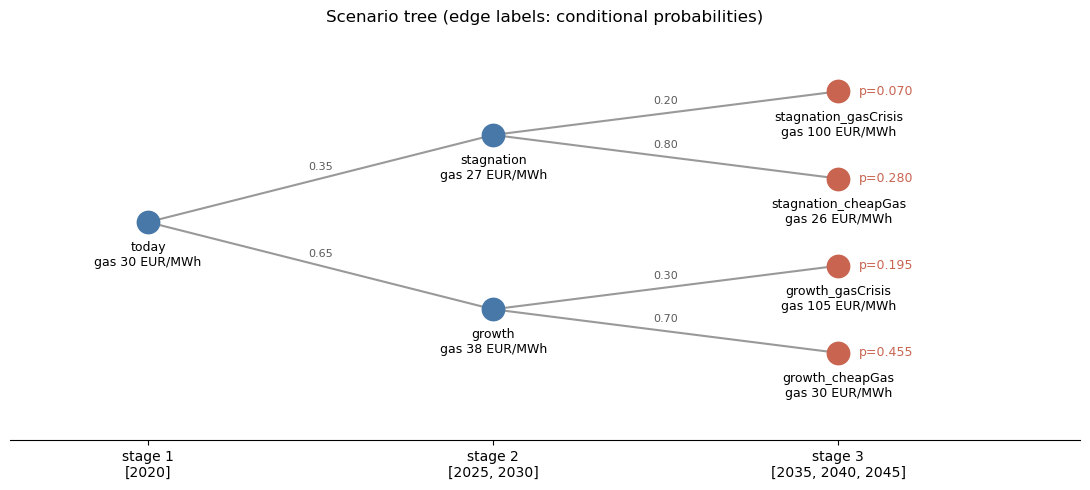

In [7]:
def plotScenarioTree(scenarioTree, annotate=None, ax=None):
    """Draw a scenario tree. Ad-hoc notebook code, see the TODO above."""
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 5))

    # Place the leaves evenly, then centre each parent above its children.
    positions = {}
    for index, leaf in enumerate(scenarioTree.scenarioNames):
        positions[leaf] = (scenarioTree.stageCount, float(index))
    for stage in range(scenarioTree.stageCount - 1, 0, -1):
        for name, nodeStage in scenarioTree.stageOfNode.items():
            if nodeStage != stage:
                continue
            children = scenarioTree.childrenOfNode[name]
            positions[name] = (
                stage,
                sum(positions[child][1] for child in children) / len(children),
            )

    for name, (x, y) in positions.items():
        parent = scenarioTree.nodes[name]["parent"]
        if parent is not None:
            px, py = positions[parent]
            ax.plot([px, x], [py, y], color="0.6", zorder=1)
            ax.text(
                (px + x) / 2,
                (py + y) / 2 + 0.08,
                f"{scenarioTree.nodes[name]['probability']:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="0.35",
            )

    for name, (x, y) in positions.items():
        isLeaf = not scenarioTree.childrenOfNode[name]
        ax.scatter([x], [y], s=260, zorder=2,
                   color="#4878A8" if not isLeaf else "#C86450")
        label = name
        if annotate is not None:
            label += "\n" + annotate(name)
        ax.text(x, y - 0.22, label, ha="center", va="top", fontsize=9)
        if isLeaf:
            ax.text(x + 0.06, y, f"p={scenarioTree.probabilityOf(name):.3f}",
                    ha="left", va="center", fontsize=9, color="#C86450")

    ax.set_xticks(range(1, scenarioTree.stageCount + 1))
    ax.set_xticklabels(
        [
            f"stage {s}\n{[esM.investmentPeriodNames[ip] for ip in periods]}"
            for s, periods in enumerate(stageInvestmentPeriods, start=1)
        ]
    )
    ax.set_yticks([])
    ax.set_xlim(0.6, scenarioTree.stageCount + 0.7)
    ax.set_ylim(-1.0, len(scenarioTree.scenarioNames) - 0.3)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.set_title("Scenario tree (edge labels: conditional probabilities)")
    return ax


def gasPrice(nodeName):
    value = scenarioTree.nodes[nodeName]["values"]["GasPurchase"]["commodityCost"]
    if isinstance(value, dict):
        value = list(value.values())[0]
    return f"gas {value * 1e6:.0f} EUR/MWh"


plotScenarioTree(scenarioTree, annotate=gasPrice)
plt.tight_layout()
plt.show()

## 6. Solve the extensive form

The extensive form builds one large deterministic-equivalent problem containing all
scenarios plus the non-anticipativity constraints, and solves it directly. It is exact, and
the right choice as long as the tree is small enough to fit into one solve.

In [8]:
resultsEF = mssp.optimizeMultiStageStochastic(
    esM,
    scenarioTree,
    stageInvestmentPeriods=stageInvestmentPeriods,
    method="ef",
    solver="gurobi",
)

print("expected net present value:", round(resultsEF.objectiveValue, 4), esM.costUnit)

[    0.00] Initializing mpi-sppy
[    0.09] Initializing SPBase


expected net present value: 338.0428 1e9 Euro


The first-stage decisions are the actual answer to the question the stochastic program asks:
what should be built **now**, before it is known which branch will occur. They are identical
in every scenario, which is what non-anticipativity means.

In [9]:
firstStage = pd.Series(
    {
        f"{compName} ({loc})": round(value, 3)
        for (_, compName, loc, _), value in resultsEF.firstStageDecisions().items()
    }
).sort_index()
firstStage.name = f"commissioned in {esM.investmentPeriodNames[0]}"
firstStage.to_frame()

,commissioned in 2020
GasTurbine (north),10.353
GasTurbine (south),11.503
Grid (north_south),0.153
Grid (south_north),0.153
Wind (north),60.000
Wind (south),31.250


## 7. Solve with progressive hedging

Progressive hedging decomposes the program into one problem per scenario and iterates until
the scenarios agree on the non-anticipative decisions. It is approximate up to the
convergence threshold, but it parallelizes across scenarios (one MPI rank per scenario) and
therefore scales to trees whose extensive form would be too large to solve at once.

In [10]:
resultsPH = mssp.optimizeMultiStageStochastic(
    esM,
    scenarioTree,
    stageInvestmentPeriods=stageInvestmentPeriods,
    method="ph",
    solver="gurobi",
    mpisppyOptions={"PHIterLimit": 50, "defaultPHrho": 1.0, "convthresh": 1e-5},
)

gap = abs(resultsPH.objectiveValue - resultsEF.objectiveValue) / abs(
    resultsEF.objectiveValue
)
print("extensive form      :", round(resultsEF.objectiveValue, 4))
print("progressive hedging :", round(resultsPH.objectiveValue, 4))
print(f"relative difference : {gap:.4%}")

[    3.77] Initializing SPBase


[    4.12] Initializing PHBase
[    4.13] Creating solvers
[    4.13] Entering solve loop in PHBase.Iter0


[    7.50] Convergence metric=0.000006 dropped below user-supplied threshold=0.000010


extensive form      : 338.0428
progressive hedging : 338.0881
relative difference : 0.0134%


## 8. Results

Every scenario keeps its own `EnergySystemModel`, on which the regular FINE result
processing has already run. The optimization summary, the plotting functions and the
optimal-value accessors therefore work exactly as they do after `esM.optimize()`.

The table below shows how the commissioning decisions adapt: the first stage is common to
all scenarios, while later stages differ according to what has been revealed by then.

In [11]:
def commissioning(esMScenario, compName):
    variable = getattr(esMScenario.pyM, "commis_srcSnk", None)
    if compName == "GasTurbine":
        variable = getattr(esMScenario.pyM, "commis_conv")
    return {
        esMScenario.investmentPeriodNames[ip]: round(
            sum(
                variable[loc, comp, ip].value
                for (loc, comp, i) in variable
                if comp == compName and i == ip
            ),
            2,
        )
        for ip in esMScenario.investmentPeriods
    }


rows = {}
for scenarioName in scenarioTree.scenarioNames:
    scenarioEsM = resultsEF.scenarioModels[scenarioName]
    for compName in ("Wind", "GasTurbine"):
        rows[(compName, scenarioName)] = commissioning(scenarioEsM, compName)

commissioningTable = pd.DataFrame(rows).T
commissioningTable.index.names = ["component", "scenario"]
commissioningTable

,,2020,2025,2030,2035,2040,2045
component,scenario,,,,,,
Wind,growth_cheapGas,91.25,0.00,0.0,0.00,0.00,0.00
GasTurbine,growth_cheapGas,21.86,6.47,0.0,4.74,3.23,58.22
Wind,growth_gasCrisis,91.25,0.00,0.0,8.75,0.00,91.25
GasTurbine,growth_gasCrisis,21.86,6.47,0.0,2.98,3.01,25.00
Wind,stagnation_cheapGas,91.25,0.00,0.0,0.00,0.00,0.00
GasTurbine,stagnation_cheapGas,21.86,0.00,0.0,1.73,0.87,53.44
Wind,stagnation_gasCrisis,91.25,0.00,0.0,8.75,0.00,91.25
GasTurbine,stagnation_gasCrisis,21.86,0.00,0.0,0.44,0.43,22.70


The columns line up with the stage structure: 2020 is stage 1 and is identical everywhere,
2025 and 2030 are stage 2 and agree within each branch of the tree, and from 2035 on every
scenario decides for itself. Where they diverge, they diverge in the expected direction: the
`gasCrisis` scenarios add wind capacity, while the `cheapGas` scenarios cover the same
demand with gas turbines instead.

Two things in the table are artefacts of the model horizon rather than results to read too
closely. The large commissioning in 2045 replaces the fleet built in 2020, which reaches the
end of its 25-year technical lifetime exactly then; and investments in the last periods look
cheap because the part of their cost that falls beyond 2045 is outside the modelled horizon.

Finally, the regular FINE optimization summary for one of the scenarios:

In [12]:
resultsEF.scenarioModels["growth_gasCrisis"].getOptimizationSummary(
    "SourceSinkModel", ip=2035, outputLevel=2
)

north  \
Component   Property         Unit                                     
Demand      operation        [GW$_{el}$*h]                 316236.0   
            operation_annual [GW$_{el}$*h/a]               316236.0   
GasPurchase NPVcontribution  [1e9 Euro]                   31.288202   
            TAC              [1e9 Euro/a]                 23.016825   
            commodCosts      [1e9 Euro/a]                 23.016825   
            operation        [GW$_{CH_{4},LHV}$*h]    219207.856327   
            operation_annual [GW$_{CH_{4},LHV}$*h/a]  219207.856327   
Wind        NPVcontribution  [1e9 Euro]                   14.319642   
            TAC              [1e9 Euro/a]                  6.548577   
            capacity         [GW$_{el}$]                       60.0   
            capexCap         [1e9 Euro/a]                  5.108577   
            commissioning    [GW$_{el}$]                        0.0   
            invest           [1e9 Euro]                         0.0   
            operation        [GW$_{el}$*h]                 183960.0   
            operation_annual [GW$_{el}$*h/a]               183960.0   
            opexCap          [1e9 Euro/a]                      1.44   

                                                              south  
Component   Property         Unit                                    
Demand      operation        [GW$_{el}$*h]                 209145.0  
            operation_annual [GW$_{el}$*h/a]               209145.0  
GasPurchase NPVcontribution  [1e9 Euro]                   28.266752  
            TAC              [1e9 Euro/a]                 20.794128  
            commodCosts      [1e9 Euro/a]                 20.794128  
            operation        [GW$_{CH_{4},LHV}$*h]    198039.316327  
            operation_annual [GW$_{CH_{4},LHV}$*h/a]  198039.316327  
Wind        NPVcontribution  [1e9 Euro]                    9.546428  
            TAC              [1e9 Euro/a]                  4.365718  
            capacity         [GW$_{el}$]                       40.0  
            capexCap         [1e9 Euro/a]                  3.405718  
            commissioning    [GW$_{el}$]                       8.75  
            invest           [1e9 Euro]                        10.5  
            operation        [GW$_{el}$*h]                  91104.0  
            operation_annual [GW$_{el}$*h/a]                91104.0  
            opexCap          [1e9 Euro/a]                      0.96